### 1. Libraries & Function


In [2]:
import os
import warnings
import logging
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from oemof.solph import (Bus, EnergySystem, Flow, Model,
                         create_time_index, processing)
from oemof.solph.components import (Sink, Source, Converter, GenericStorage)
from oemof.solph import EnergySystem
from oemof.solph import views
import oemof.solph as solph


def LCOH(invest_cost, operation_cost, heat_produced, revenue=0, i=0.05, n=20):
    pvf = ((1 + i) ** n - 1) / ((1 + i) ** n * i)
    return (invest_cost + pvf * (operation_cost - revenue)) / (
        pvf * heat_produced
    )


def epc(invest_cost, i=0.05, n=20):
    af = (i * (1 + i) ** n) / ((1 + i) ** n - 1)
    return invest_cost * af


filename = r"../2_inputs/3_OEMOF/input_data.csv"
data = pd.read_csv(filename)
solver = "gurobi"
solver_verbose = False

print(data.columns.tolist())

['thermal_demand_MW', 'electricity_price_Euro_Per_MWh', 'co2_price', 'gas_price_Euro_Per_MWh', 'biomass_Euro_Per_MWh', 'waste_Euro_Per_MWh', 'irradiance_direct_MW/m2', 'irradiance_diffuse_MW/m2']


LOSS CALCULATION AND DEMAND MODIFCATION

In [3]:
import pandas as pd

# 1. Read the CSV file
heat_losses = pd.read_csv("../3_outputs/DHNx_step2_result.csv")

# 2. Inspect the columns
# print("Columns in the dataset:")
# print(heat_losses.columns)

# 3. Sum the losses column
total_capacity = heat_losses["capacity"].sum()
total_losses = heat_losses["losses"].sum()
losses_percentage = (total_losses / total_capacity)
efficiency = 1 - losses_percentage

print(f"Total capacity          : {total_capacity:,.2f} kW")
print(f"Total losses            : {total_losses:,.2f} kW")
print(f"Losses percentage       : {losses_percentage * 100:.2f}%")
print(f"Efficiency after losses : {efficiency * 100:.2f}%")

#Add the losses to thermal demand
data["thermal_demand_MW"] = data["thermal_demand_MW"]/efficiency
data["thermal_demand_MW"].describe()


Total capacity          : 36,168.34 kW
Total losses            : 2,793.49 kW
Losses percentage       : 7.72%
Efficiency after losses : 92.28%


count    8760.000000
mean        4.146314
std         2.048431
min         1.437923
25%         2.150683
50%         4.005391
75%         5.706442
max        10.037993
Name: thermal_demand_MW, dtype: float64

### 2. Energy System

In [12]:
capacity_gas_heat = 3         # MW
capacity_biomass_chp = 4        # MW
capacity_wte_chp = 4        # MW
max_heat_hp = 3         # MW
area_m2 = 4000     # m2


datetimeindex = create_time_index(2023, number=len(data))
energysystem = EnergySystem(timeindex=datetimeindex, infer_last_interval=False)

electrical_bus = Bus(label="electrical_bus")  # Electricity bus
thermal_bus = Bus(label="thermal_bus")  # Heat bus
gas_bus = Bus(label="gas_bus")  # Natural gas bus
biomass_bus = Bus(label="biomass_bus")  # Biomass bus
waste_bus = Bus(label="waste_bus")  # Municipal Waste bus
wasteheat_bus = Bus(label="wasteheat_bus")  # Waste Heat bus
energysystem.add(electrical_bus, thermal_bus, gas_bus,
                 biomass_bus, waste_bus, wasteheat_bus)

# ------------------------------------------------------------------
# SOURCES
# ------------------------------------------------------------------
energysystem.add(
    Source(
        label="natural_gas",
        outputs={gas_bus: Flow(variable_costs=data["gas_price_Euro_Per_MWh"])},
    )
)

energysystem.add(
    Source(
        label="electricity_grid",
        outputs={electrical_bus: Flow(variable_costs=data["electricity_price_Euro_Per_MWh"])},
    )
)

energysystem.add(
    Source(
        label="biomass",
        outputs={biomass_bus: Flow(variable_costs=data["biomass_Euro_Per_MWh"])},
    )
)

energysystem.add(
    Source(
        label="waste",
        outputs={waste_bus: Flow(variable_costs=data["waste_Euro_Per_MWh"])},
    )
)

energysystem.add(
    Source(
        label="waste_heat",
        outputs={wasteheat_bus: Flow(variable_costs=0, nominal_value=0.5, max=1.0)},
    )
)

# ------------------------------------------------------------------
# LOADS
# ------------------------------------------------------------------
thermal_peak = data["thermal_demand_MW"].max()

energysystem.add(
    Sink(
        label="thermal_demand",
        inputs={
            thermal_bus: Flow(
                nominal_value=thermal_peak,
                fix=data["thermal_demand_MW"] / thermal_peak,
            )
        },
    )
)

energysystem.add(
    Sink(
        label="excess_electricity",
        inputs={
            electrical_bus: Flow(
                variable_costs=data["electricity_price_Euro_Per_MWh"] * -1
            )
        },
    )
)

# ------------------------------------------------------------------
# CONVERTERS
# 1) Natural Gas DH Only Unit
# ------------------------------------------------------------------
efficiency_gas_heat = 0.93
startup_cost_gas = 8.0   # €/start
vom_heat = 0.64          # €/MWh_heat

energysystem.add(
    solph.components.Converter(
        label="heat_gas",
        inputs={gas_bus: solph.Flow()},
        outputs={
            thermal_bus: solph.Flow(
                nominal_value=capacity_gas_heat,
                min=0.1,
                variable_costs=vom_heat,   # O&M only
#                nonconvex=solph.NonConvex(
#                    startup_costs=startup_cost_gas,
#                    shutdown_costs=0,
#                    # minimum_uptime=1,
#                    # minimum_downtime=1,
#                    # initial_status=0,
#                ),
            )
        },
        conversion_factors={thermal_bus: efficiency_gas_heat},
    )
)

#from oemof import solph
from oemof.solph import Flow

# ------------------------------------------------------------------
#2. Biomass CHP parameters
# ------------------------------------------------------------------

# --- efficiencies from your datasheet ---
efficiency_biomass_chp_elc = 0.14        # net electric efficiency (CHP mode)
efficiency_biomass_chp_th_rel = 0.97     # "97% of remaining energy"
efficiency_biomass_chp_th = (
    1 - efficiency_biomass_chp_elc
) * efficiency_biomass_chp_th_rel        # ≈ 0.83 absolute heat efficiency

eta_el_cond_bio = 0.20   # assumed condensing electric efficiency (no heat)

# ---------- derive start-up / shutdown costs from your data ----------
eta_tot_biomass = efficiency_biomass_chp_elc + efficiency_biomass_chp_th  # ≈ 0.97
avg_biomass_price = float(data["biomass_Euro_Per_MWh"].mean())            # €/MWh_fuel

# fuel input at full CHP load (MW_fuel)
fuel_input_full = capacity_biomass_chp / eta_tot_biomass

# variable cost per hour at full load (€/h)
C_var_full = fuel_input_full * avg_biomass_price

# assume "equivalent hours" of variable cost per start
equiv_hours = 4.0
biomass_startup_cost = equiv_hours * C_var_full     # €/start
biomass_shutdown_cost = 0.2 * biomass_startup_cost  # €/shutdown

# you can use these also for a separate biomass boiler if needed
boiler_startup_cost  = biomass_startup_cost
boiler_shutdown_cost = biomass_shutdown_cost

# ---------- non-convex behaviour settings ----------
biomass_min_load     = 0.6    # ≥ 60% of fuel capacity when ON
biomass_min_uptime   = 96     # hours
biomass_min_downtime = 48     # hours

# ------------------------------------------------------------------
# Biomass CHP as ExtractionTurbineCHP
# ------------------------------------------------------------------

energysystem.add(
    solph.components.ExtractionTurbineCHP(
        label="chp_biomass",
        inputs={
            biomass_bus: Flow(
                nominal_value=capacity_biomass_chp,   # MW_fuel capacity
                min=biomass_min_load,                 # min load when ON
                nonconvex=solph.NonConvex(
                    startup_costs=biomass_startup_cost,
                    shutdown_costs=biomass_shutdown_cost,
                    minimum_uptime=biomass_min_uptime,
                    minimum_downtime=biomass_min_downtime,
                    initial_status=1,
                ),
            )
        },
        outputs={
            electrical_bus: Flow(),
            thermal_bus:    Flow(variable_costs=1.45), # €/MWh_th
        },
        # CHP-mode efficiencies (back-pressure / extraction region)
        conversion_factors={
            electrical_bus: efficiency_biomass_chp_elc,
            thermal_bus:    efficiency_biomass_chp_th,
        },
        # Condensing-mode electric efficiency (no heat)
        conversion_factor_full_condensation={
            electrical_bus: eta_el_cond_bio,
        },
    )
)

from oemof import solph
from oemof.solph import Flow

# ------------------------------------------------------------------
# Waste-to-Energy (WtE) CHP parameters
# ------------------------------------------------------------------

# --- efficiencies from your datasheet ---
efficiency_wte_chp_elc = 0.22          # net electric efficiency (CHP mode)
efficiency_wte_chp_th_rel = 0.80       # "80% of remaining energy"
efficiency_wte_chp_th = (
    1 - efficiency_wte_chp_elc
) * efficiency_wte_chp_th_rel          # ≈ 0.624 absolute heat efficiency

# assumed condensing electric efficiency (no heat)
eta_el_cond_wte = 0.26                 # tune if you have better data

# ---------- derive start-up / shutdown costs from your data ----------
# total CHP efficiency
eta_tot_wte = efficiency_wte_chp_elc + efficiency_wte_chp_th

# average fuel (waste) price in €/MWh_fuel
# NOTE: make sure this column exists in your `data` DataFrame
avg_wte_price = float(data["waste_Euro_Per_MWh"].mean())

# fuel input at full CHP load (MW_fuel)
fuel_input_full_wte = capacity_wte_chp / eta_tot_wte

# variable cost per hour at full load (€/h)
C_var_full_wte = fuel_input_full_wte * avg_wte_price

# assume "equivalent hours" of variable cost per start
equiv_hours_wte = 4.0
wte_startup_cost = equiv_hours_wte * C_var_full_wte      # €/start
wte_shutdown_cost = 0.2 * wte_startup_cost               # €/shutdown

# ---------- non-convex behaviour settings ----------
wte_min_load     = 0.5    # ≥ 50% of fuel capacity when ON
wte_min_uptime   = 48     # hours
wte_min_downtime = 24     # hours

# ------------------------------------------------------------------
# Waste-to-Energy CHP as ExtractionTurbineCHP
# ------------------------------------------------------------------

energysystem.add(
    solph.components.ExtractionTurbineCHP(
        label="waste_to_energy",
        inputs={
            waste_bus: Flow(
                nominal_value=capacity_wte_chp,    # MW_fuel capacity
                min=wte_min_load,                  # minimum load when ON
                nonconvex=solph.NonConvex(
                    startup_costs=wte_startup_cost,
                    shutdown_costs=wte_shutdown_cost,
                    minimum_uptime=wte_min_uptime,
                    minimum_downtime=wte_min_downtime,
                    initial_status=1,
                ),
            )
        },
        outputs={
            electrical_bus: Flow(),
            thermal_bus:    Flow(variable_costs=6.3),
        },
        # CHP-mode efficiencies (back-pressure / extraction region)
        conversion_factors={
            electrical_bus: efficiency_wte_chp_elc,
            thermal_bus:    efficiency_wte_chp_th,
        },
        # Condensing-mode electric efficiency (no heat)
        conversion_factor_full_condensation={
            electrical_bus: eta_el_cond_wte,
        },
    )
)


# ------------------------------------------------------------------
# 4) Heat Pump
# ------------------------------------------------------------------
cop_hp = 3.5

energysystem.add(
    solph.components.Converter(
        label="heat_pump",
        inputs={
            electrical_bus: Flow(),  # electricity input
            wasteheat_bus: Flow(),   # low-temperature/source heat
        },
        outputs={
            thermal_bus: Flow(nominal_value=max_heat_hp, variable_costs=2.86),  # max thermal capacity [MW]
        },
        conversion_factors={
            electrical_bus: 1 / cop_hp,              # electrical input
            wasteheat_bus: (cop_hp - 1) / cop_hp,    # source heat input
        },
    )
)

# ------------------------------------------------------------------
# 5) Solar Thermal Plant
# ------------------------------------------------------------------
tilt_deg = 45              # collector tilt
eta = 0.48                 # annual efficiency
annual_input = 1.05        # MWh_i per m2 per year
pump_fraction = 0.01       # 1% parasitic load

dni = data["irradiance_direct_MW/m2"].clip(lower=0)
dhi = data["irradiance_diffuse_MW/m2"].clip(lower=0)
cosZ = 0.3                 # simple average factor
ghi = dhi + dni * cosZ

tilt = np.deg2rad(tilt_deg)
Rb = 1.0                   # simple assumption (no tracking)

G_tilt = (
    dni * Rb +                                # beam on tilt
    dhi * (1 + np.cos(tilt)) / 2 +           # diffuse on tilt
    ghi * 0.2 * (1 - np.cos(tilt)) / 2       # ground reflection (albedo = 0.2)
)

G_tilt = G_tilt.clip(lower=0)
G_MWh = G_tilt / 1e6                          # W/m2 → MWh/m2 over 1h

scale = annual_input / G_MWh.sum()
G_input = G_MWh * scale                       # MWh_i/m2/h (scaled)
G_output = G_input * eta                      # MWh_th/m2/h

solar_thermal_MW = G_output * area_m2         # MWh/h ≈ MW
pump_MW = pump_fraction * solar_thermal_MW

print("Solar thermal peak (MW):", solar_thermal_MW.max())
print("Annual thermal output (MWh):", solar_thermal_MW.sum())

Q_nominal = solar_thermal_MW.max()
solar_profile_pu = solar_thermal_MW / Q_nominal

energysystem.add(
    Source(
        label="solar_thermal",
        outputs={
            thermal_bus: Flow(
                nominal_value=Q_nominal,
                max=solar_profile_pu.values,
            )
        },
    )
)

# ------------------------------------------------------------------
# HEAT STORAGE
# ------------------------------------------------------------------
storage_capacity_MWh = 80   # max stored heat [MWh]
max_charge_MW = 10          # max charging power [MW]
max_discharge_MW = 10       # max discharging power [MW]
loss_rate = 0.002           # fraction of energy lost per hour
initial_soc = 0.2           # 20% full at t=0
eff_charge = 0.98           # charging efficiency
eff_discharge = 0.98        # discharging efficiency

#energysystem.add(
#    GenericStorage(
#        label="heat_storage",
#        nominal_storage_capacity=80,
#        inputs={thermal_bus: Flow(nominal_value=10)},   # charge limit [kW]
#        outputs={thermal_bus: Flow(nominal_value=10)},  # discharge limit [kW]
#        loss_rate=0.001,
#        inflow_conversion_factor=1.0,
#        outflow_conversion_factor=0.99
#    )
#)

#energysystem.add(
#    GenericStorage(
#        label="heat_storage",
#        inputs={
#            thermal_bus: Flow(
#                nominal_value=max_charge_MW,
#                max=1.0,   # 0..1 * nominal_value
#            )
#        },
#        outputs={
#            thermal_bus: Flow(
#                nominal_value=max_discharge_MW,
#                max=1.0,   # 0..1 * nominal_value
#            )
#        },
#        nominal_storage_capacity=storage_capacity_MWh,
#        loss_rate=loss_rate,             # standing losses per timestep
#        initial_storage_level=initial_soc,  # relative (0..1)
#        inflow_conversion_factor=eff_charge,
#        outflow_conversion_factor=eff_discharge,
#        min_storage_level=0.2,
#        max_storage_level=0.8,
#    )
#)

# ------------------------------------------------------------------
# OPTIMIZE
# ------------------------------------------------------------------
model = Model(energysystem, name="District Heating Optimization Model")
logging.info("Solving the optimization problem.")

model.solve(
    solver="gurobi",
    solve_kwargs={"tee": True},
    #cmdline_options={"MIPGap": "0.1"},
),


energysystem.results["main"] = processing.results(model, remove_last_time_point=True)
#energysystem.results["main"] = processing.results(model)
energysystem.results["meta"] = processing.meta_results(model)

output_file = os.path.join(os.getcwd(), "../3_outputs/OEMOF_step3_results.xlsx")
energysystem.dump(os.getcwd(), "../3_outputs/OEMOF_step3_results.xlsx")
logging.info("Results have been dumped.")

results = energysystem.results["main"]

Solar thermal peak (MW): 1.68767712986937
Annual thermal output (MWh): 2015.9999999999998


This is usually indicative of a modelling error.
To avoid this warning, use block.del_component() and block.add_component().
This is usually indicative of a modelling error.
To avoid this warning, use block.del_component() and block.add_component().


Set parameter Username
Set parameter LicenseID to value 2729760
Academic license - for non-commercial use only - expires 2026-10-30
Read LP format model from file C:\Users\ardia\AppData\Local\Temp\tmpx8330mz0.pyomo.lp
Reading time = 1.01 seconds
x1: 236224 rows, 227616 columns, 2409668 nonzeros
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (win64 - Windows 11.0 (26100.2))

CPU model: Intel(R) Core(TM) Ultra 7 155H, instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 22 logical processors, using up to 22 threads

Optimize a model with 236224 rows, 227616 columns and 2409668 nonzeros
Model fingerprint: 0x7841aacf
Variable types: 175200 continuous, 52416 integer (52416 binary)
Coefficient statistics:
  Matrix range     [2e-01, 1e+02]
  Objective range  [1e-02, 6e+02]
  Bounds range     [1e-03, 4e+00]
  RHS range        [1e+00, 5e+01]
Presolve removed 152205 rows and 150298 columns
Presolve time: 4.09s
Presolved: 84019 rows, 77318 columns, 1585956 nonzeros
Variable types: 3

c:\Users\ardia\miniconda3\envs\env_P2\lib\site-packages\oemof\network\energy_system.py:256: FutureWarning: Parameter 'dpath' will be removed in a future version. You can give the directory as part of the filename and set 'consider_dpath' to False to suppress this waring.
  warnings.warn(


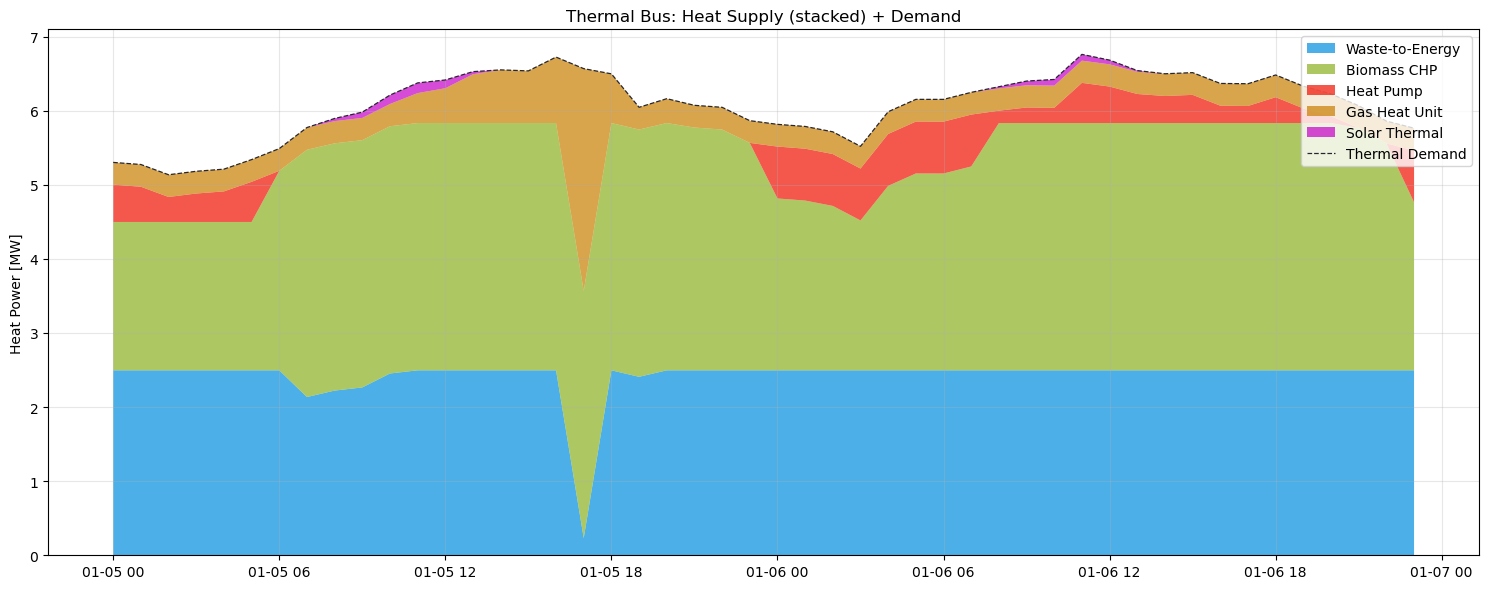

In [13]:
import matplotlib.pyplot as plt
from oemof.solph import views


thermal_bus_view = views.node(results, "thermal_bus")
seq = thermal_bus_view["sequences"].iloc[:-1]

start = "2023-01-05"
end = "2023-01-06"

seq = seq.loc[start:end]

# Column names from your results
col_wte = (("waste_to_energy", "thermal_bus"), "flow")
col_biomass = (("chp_biomass", "thermal_bus"), "flow")
col_gas = (("heat_gas", "thermal_bus"), "flow")
col_hp = (("heat_pump", "thermal_bus"), "flow")
col_solar_th = (("solar_thermal", "thermal_bus"), "flow")

has_hp = col_hp in seq.columns
has_solar_th = col_solar_th in seq.columns

# Desired order from BOTTOM (first) → TOP (last)
stack_order = [
    
    "wte", "biomass",    "hp",

    "gas",    "solar_th",

]
components = {
    "biomass": {
        "series": seq[col_biomass],
        "label": "Biomass CHP",
        "color": "#8AB020",
    },
    "gas": {
        "series": seq[col_gas],
        "label": "Gas Heat Unit",
        "color": "#C87E00",
    },
    "wte": {
        "series": seq[col_wte],
        "label": "Waste-to-Energy",
        "color": "#008DDF",
    },
    "hp": {
        "series": seq[col_hp] if has_hp else None,
        "label": "Heat Pump",
        "color": "#F01000",
    },
    "solar_th": {
        "series": seq[col_solar_th] if has_solar_th else None,
        "label": "Solar Thermal",
        "color": "#C500C8",
    },
}
supply_components = []
labels = []
colors = []

for key in stack_order:
    c = components[key]
    if c["series"] is not None:
        supply_components.append(c["series"])
        labels.append(c["label"])
        colors.append(c["color"])
plt.figure(figsize=(15, 6))

plt.stackplot(
    seq.index,
    *supply_components,
    labels=labels,
    colors=colors,
    alpha=0.7,
)

plt.plot(
    seq.index,
    seq[(("thermal_bus", "thermal_demand"), "flow")],
    label="Thermal Demand",
    color="#262630",
    linestyle="--",
    linewidth=0.9,
)

plt.title("Thermal Bus: Heat Supply (stacked) + Demand")
plt.ylabel("Heat Power [MW]")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

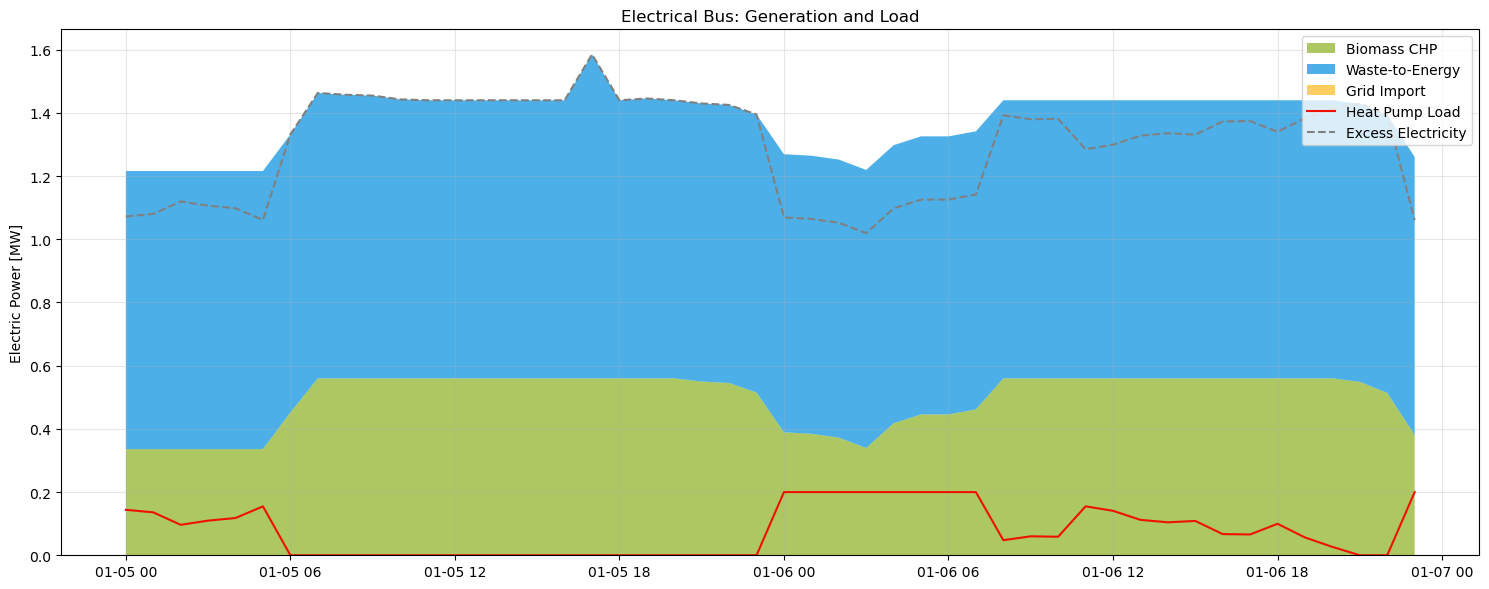

In [14]:
electricity_bus_view = views.node(results, "electrical_bus")
seq_elec = electricity_bus_view["sequences"].iloc[:-1]

# Define time range
start = "2023-01-05"
end = "2023-01-06"
seq_elec = seq_elec.loc[start:end]

# Column names for electricity flows
col_chp_biomass_elc = (("chp_biomass", "electrical_bus"), "flow")
col_wte_elc = (("waste_to_energy", "electrical_bus"), "flow")
col_grid_import = (("electricity_grid", "electrical_bus"), "flow")
col_hp_load = (("electrical_bus", "heat_pump"), "flow")
col_excess = (("electrical_bus", "excess_electricity"), "flow")

# Plot electricity balance
fig, ax = plt.subplots(figsize=(15, 6))

# Supply side (stacked)
supply = [
    seq_elec[col_chp_biomass_elc],
    seq_elec[col_wte_elc],
    seq_elec[col_grid_import],
]

ax.stackplot(
    seq_elec.index,
    supply,
    labels=["Biomass CHP", "Waste-to-Energy", "Grid Import"],
    colors=["#8AB020", "#008DDF", "#FFB81C"],
    alpha=0.7,
)

# Demand side (plot as lines)
ax.plot(
    seq_elec.index,
    seq_elec[col_hp_load],
    label="Heat Pump Load",
    color="#F01000",
    linewidth=1.5,
)

ax.plot(
    seq_elec.index,
    seq_elec[col_excess],
    label="Excess Electricity",
    color="#808080",
    linewidth=1.5,
    linestyle="--",
)

ax.set_ylabel("Electric Power [MW]")
ax.set_title("Electrical Bus: Generation and Load")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

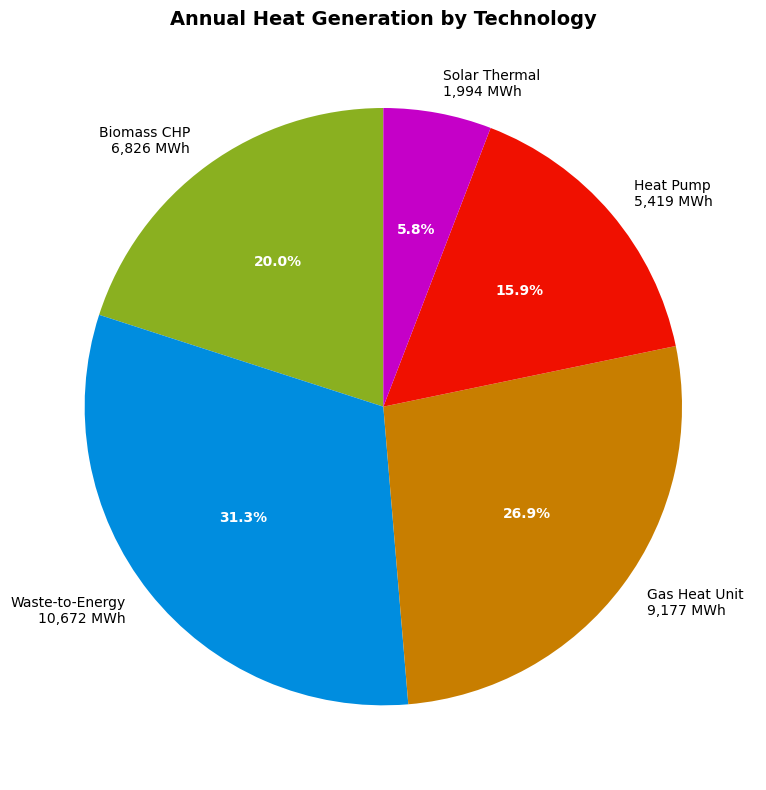


Annual Heat Generation Summary:
Biomass CHP..............     6826.4 MWh ( 20.0%)
Waste-to-Energy..........    10672.1 MWh ( 31.3%)
Gas Heat Unit............     9177.4 MWh ( 26.9%)
Heat Pump................     5418.7 MWh ( 15.9%)
Solar Thermal............     1993.5 MWh (  5.8%)
Total....................    34088.1 MWh


In [15]:
import pandas as pd
from oemof.solph import views
import matplotlib.pyplot as plt

# Extract thermal bus sequences
thermal_bus_view = views.node(results, "thermal_bus")
seq = thermal_bus_view["sequences"].iloc[:-1]

# Define technology columns
tech_cols = {
    "Biomass CHP": (("chp_biomass", "thermal_bus"), "flow"),
    "Waste-to-Energy": (("waste_to_energy", "thermal_bus"), "flow"),
    "Gas Heat Unit": (("heat_gas", "thermal_bus"), "flow"),
    "Heat Pump": (("heat_pump", "thermal_bus"), "flow"),
    "Solar Thermal": (("solar_thermal", "thermal_bus"), "flow")
}

# Calculate annual heat generation for each technology
annual_generation = {}
for tech, col in tech_cols.items():
    if col in seq.columns:
        annual_generation[tech] = seq[col].sum()
    else:
        annual_generation[tech] = 0.0

# Prepare labels with MWh values
labels = [
    f"{tech}\n{value:,.0f} MWh"
    for tech, value in annual_generation.items()
]

# Create pie chart
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#8AB020', '#008DDF', '#C87E00', '#F01000', '#C500C8']
wedges, texts, autotexts = ax.pie(
    annual_generation.values(),
    labels=labels,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90
)

# Enhance text
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(10)
    autotext.set_weight('bold')

ax.set_title('Annual Heat Generation by Technology', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print summary
print("\nAnnual Heat Generation Summary:")
print("=" * 50)
total = sum(annual_generation.values())
for tech, value in annual_generation.items():
    pct = (value / total) * 100
    print(f"{tech:.<25} {value:>10.1f} MWh ({pct:>5.1f}%)")
print("=" * 50)
print(f"{'Total':.<25} {total:>10.1f} MWh")

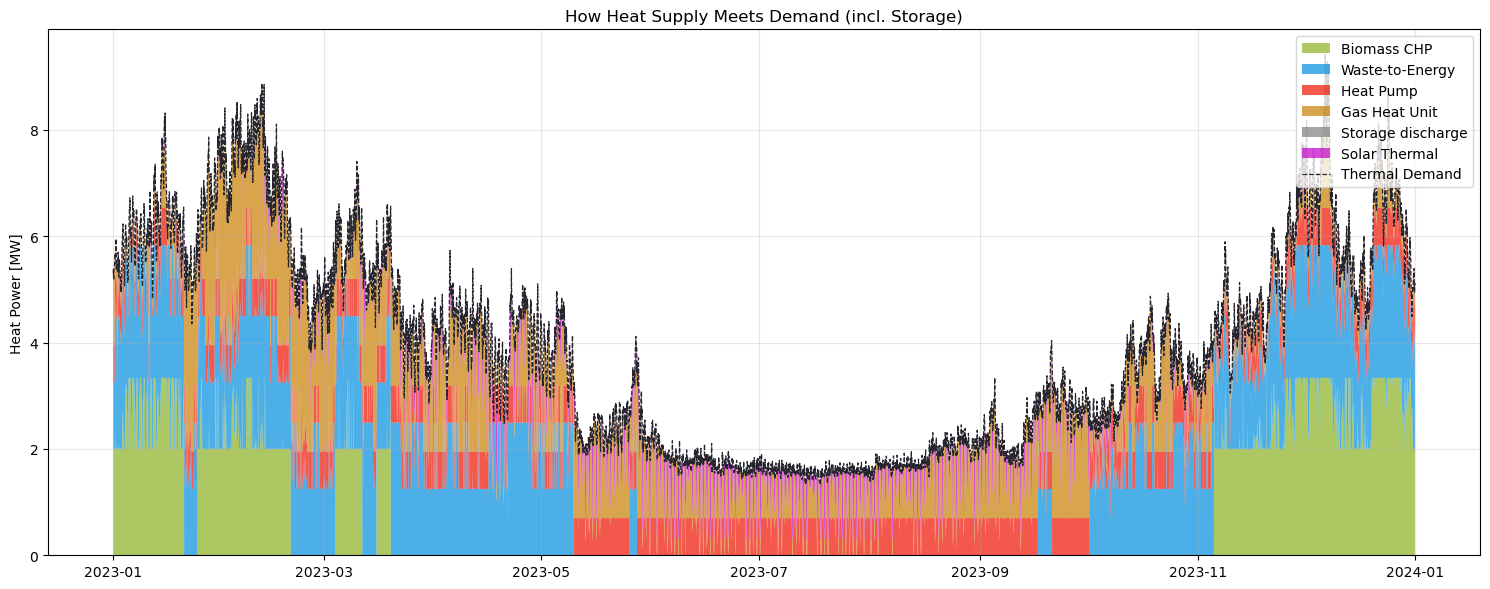

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from oemof.solph import views

# --------- THERMAL BUS RESULTS ---------
thermal_bus_view = views.node(results, "thermal_bus")
seq = thermal_bus_view["sequences"].iloc[:-1]  # drop last NaN row

start = "2023-01-01"
end   = "2023-12-31"
seq = seq.loc[start:end]

# Column names from your results
col_wte       = (("waste_to_energy", "thermal_bus"), "flow")
col_biomass   = (("chp_biomass",     "thermal_bus"), "flow")
col_gas       = (("heat_gas",        "thermal_bus"), "flow")
col_hp        = (("heat_pump",       "thermal_bus"), "flow")
col_solar_th  = (("solar_thermal",   "thermal_bus"), "flow")

# Storage flows (bus ↔ storage)
col_storage_discharge = (("heat_storage", "thermal_bus"), "flow")   # discharge to bus
col_storage_charge    = (("thermal_bus", "heat_storage"), "flow")   # charge from bus

has_hp          = col_hp in seq.columns
has_solar_th    = col_solar_th in seq.columns
has_storage_dis = col_storage_discharge in seq.columns
has_storage_ch  = col_storage_charge in seq.columns

# --------- GROSS SUPPLY COMPONENTS (to bus) ---------
components = {
    "Biomass CHP":       seq[col_biomass],
    "Waste-to-Energy":   seq[col_wte],
    "Heat Pump":         seq[col_hp] if has_hp else 0.0,
    "Gas Heat Unit":     seq[col_gas],
    "Storage discharge": seq[col_storage_discharge] if has_storage_dis else 0.0,
    "Solar Thermal":     seq[col_solar_th] if has_solar_th else 0.0,
}

colors = {
    "Biomass CHP":       "#8AB020",
    "Waste-to-Energy":   "#008DDF",
    "Heat Pump":         "#F01000",
    "Gas Heat Unit":     "#C87E00",
    "Storage discharge": "#7F7F7F",
    "Solar Thermal":     "#C500C8",
}

# Total gross thermal supply into bus
total_supply = sum(components.values())

# Storage charging from bus (0 if not present)
storage_charge = seq[col_storage_charge] if has_storage_ch else 0.0

# Net heat that actually serves demand
net_to_demand = (total_supply - storage_charge).clip(lower=0)

# --------- REDISTRIBUTE NET HEAT TO TECHNOLOGIES ---------
# For each timestep, allocate net_to_demand according to each tech's share of total_supply
stack_series = []
labels = []
stack_colors = []

# avoid division by zero
denom = total_supply.replace(0, np.nan)

for name, series in components.items():
    # series may be 0.0 (scalar) if tech not present
    if isinstance(series, (int, float)):
        tech_net = total_supply * 0  # all zeros
    else:
        share = (series / denom).fillna(0)
        tech_net = share * net_to_demand
    stack_series.append(tech_net)
    labels.append(name)
    stack_colors.append(colors[name])

# Demand series
demand_series = seq[(("thermal_bus", "thermal_demand"), "flow")]

# --------- PLOTTING ---------
fig, ax1 = plt.subplots(figsize=(15, 6))

# STACKED "HEAT TO DEMAND" (left axis)
ax1.stackplot(
    seq.index,
    *stack_series,
    labels=labels,
    colors=stack_colors,
    alpha=0.7,
)

# Thermal demand – should now match the top of the stack
ax1.plot(
    seq.index,
    demand_series,
    label="Thermal Demand",
    color="#262630",
    linestyle="--",
    linewidth=0.9,
)

ax1.set_ylabel("Heat Power [MW]")
ax1.set_title("How Heat Supply Meets Demand (incl. Storage)")
ax1.grid(True, alpha=0.3)

# --------- STORAGE SOC (right axis) ---------
#storage_view = views.node(results, "heat_storage")
#storage_seq = storage_view["sequences"].iloc[:-1].loc[start:end]

## Auto-detect SOC column
#soc_cols = [c for c in storage_seq.columns if c[1] == "storage_content"]
#soc = storage_seq[soc_cols[0]].clip(lower=0)
#
#soc_pu = soc / storage_capacity_MWh  # 0–1
#
#ax2 = ax1.twinx()
#ax2.plot(
#    soc.index,
#    soc_pu,
#    color="black",
#    linewidth=1.2,
#    linestyle=":",
#    label="Storage SoC",
#)
#ax2.set_ylabel("State of Charge [0–1]")
#ax2.set_ylim(0, 1)
#
# --------- MERGED LEGEND ---------
lines_1, labels_1 = ax1.get_legend_handles_labels()
#lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 , labels_1 , loc="upper right")

plt.tight_layout()
plt.show()


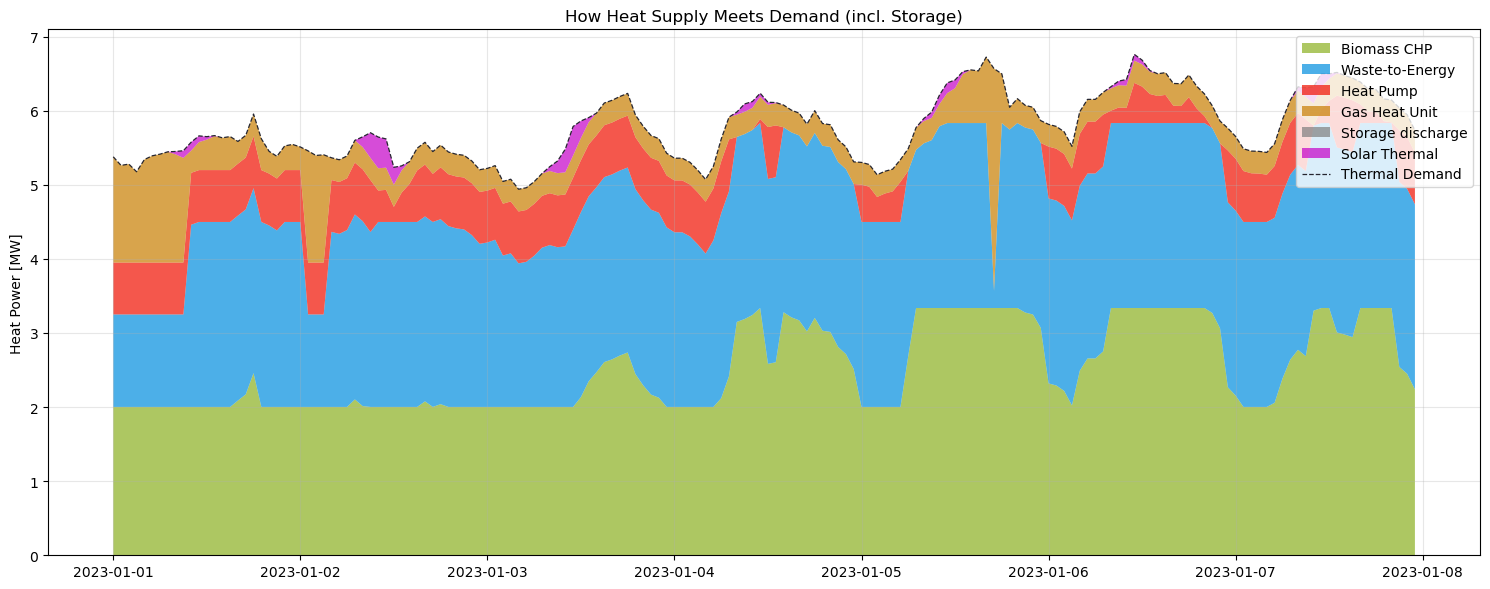

In [17]:
import matplotlib.pyplot as plt
import numpy as np
from oemof.solph import views

# --------- THERMAL BUS RESULTS ---------
thermal_bus_view = views.node(results, "thermal_bus")
seq = thermal_bus_view["sequences"].iloc[:-1]  # drop last NaN row

start = "2023-01-01"
end   = "2023-01-07"
seq = seq.loc[start:end]

# Column names from your results
col_wte       = (("waste_to_energy", "thermal_bus"), "flow")
col_biomass   = (("chp_biomass",     "thermal_bus"), "flow")
col_gas       = (("heat_gas",        "thermal_bus"), "flow")
col_hp        = (("heat_pump",       "thermal_bus"), "flow")
col_solar_th  = (("solar_thermal",   "thermal_bus"), "flow")

# Storage flows (bus ↔ storage)
col_storage_discharge = (("heat_storage", "thermal_bus"), "flow")   # discharge to bus
col_storage_charge    = (("thermal_bus", "heat_storage"), "flow")   # charge from bus

has_hp          = col_hp in seq.columns
has_solar_th    = col_solar_th in seq.columns
has_storage_dis = col_storage_discharge in seq.columns
has_storage_ch  = col_storage_charge in seq.columns

# --------- GROSS SUPPLY COMPONENTS (to bus) ---------
components = {
    "Biomass CHP":       seq[col_biomass],
    "Waste-to-Energy":   seq[col_wte],
    "Heat Pump":         seq[col_hp] if has_hp else 0.0,
    "Gas Heat Unit":     seq[col_gas],
    "Storage discharge": seq[col_storage_discharge] if has_storage_dis else 0.0,
    "Solar Thermal":     seq[col_solar_th] if has_solar_th else 0.0,
}

colors = {
    "Biomass CHP":       "#8AB020",
    "Waste-to-Energy":   "#008DDF",
    "Heat Pump":         "#F01000",
    "Gas Heat Unit":     "#C87E00",
    "Storage discharge": "#7F7F7F",
    "Solar Thermal":     "#C500C8",
}

# Total gross thermal supply into bus
total_supply = sum(components.values())

# Storage charging from bus (0 if not present)
storage_charge = seq[col_storage_charge] if has_storage_ch else 0.0

# Net heat that actually serves demand
net_to_demand = (total_supply - storage_charge).clip(lower=0)

# --------- REDISTRIBUTE NET HEAT TO TECHNOLOGIES ---------
# For each timestep, allocate net_to_demand according to each tech's share of total_supply
stack_series = []
labels = []
stack_colors = []

# avoid division by zero
denom = total_supply.replace(0, np.nan)

for name, series in components.items():
    # series may be 0.0 (scalar) if tech not present
    if isinstance(series, (int, float)):
        tech_net = total_supply * 0  # all zeros
    else:
        share = (series / denom).fillna(0)
        tech_net = share * net_to_demand
    stack_series.append(tech_net)
    labels.append(name)
    stack_colors.append(colors[name])

# Demand series
demand_series = seq[(("thermal_bus", "thermal_demand"), "flow")]

# --------- PLOTTING ---------
fig, ax1 = plt.subplots(figsize=(15, 6))

# STACKED "HEAT TO DEMAND" (left axis)
ax1.stackplot(
    seq.index,
    *stack_series,
    labels=labels,
    colors=stack_colors,
    alpha=0.7,
)

# Thermal demand – should now match the top of the stack
ax1.plot(
    seq.index,
    demand_series,
    label="Thermal Demand",
    color="#262630",
    linestyle="--",
    linewidth=0.9,
)

ax1.set_ylabel("Heat Power [MW]")
ax1.set_title("How Heat Supply Meets Demand (incl. Storage)")
ax1.grid(True, alpha=0.3)

## --------- STORAGE SOC (right axis) ---------
#storage_view = views.node(results, "heat_storage")
#storage_seq = storage_view["sequences"].iloc[:-1].loc[start:end]
#
## Auto-detect SOC column
#soc_cols = [c for c in storage_seq.columns if c[1] == "storage_content"]
#soc = storage_seq[soc_cols[0]].clip(lower=0)
#
#soc_pu = soc / storage_capacity_MWh  # 0–1
#
#ax2 = ax1.twinx()
#ax2.plot(
#    soc.index,
#    soc_pu,
#    color="black",
#    linewidth=1.2,
#    linestyle=":",
#    label="Storage SoC",
#)
#ax2.set_ylabel("State of Charge [0–1]")
#ax2.set_ylim(0, 1)

# --------- MERGED LEGEND ---------
lines_1, labels_1 = ax1.get_legend_handles_labels()
#lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 , labels_1 , loc="upper right")

plt.tight_layout()
plt.show()


C:\Users\ardia\AppData\Local\Temp\ipykernel_3012\3243583346.py:27: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  annual_sum = seq[col].resample('Y').sum().iloc[0]


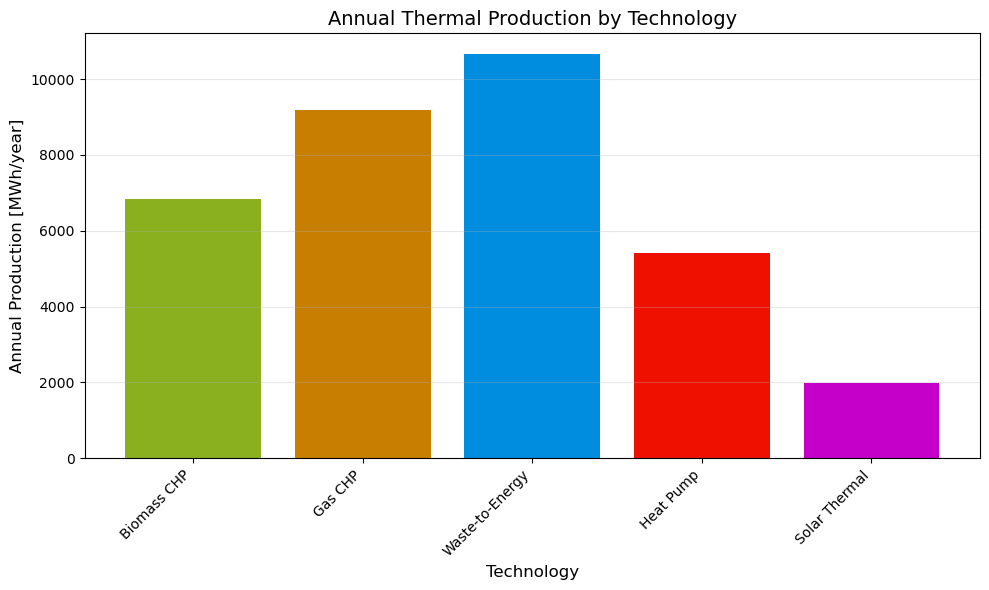

In [18]:
import matplotlib.pyplot as plt
import pandas as pd
from oemof.solph import views

# Extract sequences
thermal_bus_view = views.node(results, "thermal_bus")
seq = thermal_bus_view["sequences"].iloc[:-1]  # drop last NaN row

# Ensure datetime index
if not isinstance(seq.index, pd.DatetimeIndex):
    seq.index = pd.to_datetime(seq.index)

# Define the technology columns
tech_cols = {
    "Biomass CHP": (("chp_biomass", "thermal_bus"), "flow"),
    "Gas CHP":     (("heat_gas",     "thermal_bus"), "flow"),
    "Waste-to-Energy": (("waste_to_energy", "thermal_bus"), "flow"),
    "Heat Pump":   (("heat_pump",   "thermal_bus"), "flow"),
    "Solar Thermal": (("solar_thermal", "thermal_bus"), "flow")
}

# Aggregate annual production by technology
annual_yields = {}
for tech, col in tech_cols.items():
    if col in seq.columns:
        # first year only (adjust if multi-year)
        annual_sum = seq[col].resample('Y').sum().iloc[0]
        annual_yields[tech] = annual_sum
    else:
        # Skip if technology not present
        annual_yields[tech] = 0.0

# Prepare for bar chart
technologies = list(annual_yields.keys())
values = [annual_yields[tech] for tech in technologies]

plt.figure(figsize=(10, 6))
bars = plt.bar(technologies, values, color=[
               '#8AB020', '#C87E00', '#008DDF', '#F01000', '#C500C8'])
plt.xlabel('Technology', fontsize=12)
plt.ylabel('Annual Production [MWh/year]', fontsize=12)
plt.title('Annual Thermal Production by Technology', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
import pandas as pd
from pyomo.opt import TerminationCondition, SolverStatus

meta = energysystem.results["meta"]

print("\n==================== META RESULTS ====================\n")

# Objective
print(f"Objective value             : {float(meta['objective']):,.3f}")

# Problem information
problem = meta.get("problem", {})
print("\n--- Problem Structure ---")
print(f"Name                        : {problem.get('Name')}")
print(
    f"Constraints                 : {problem.get('Number of constraints'):,}")
print(f"Variables                   : {problem.get('Number of variables'):,}")
print(f"Nonzeros                    : {problem.get('Number of nonzeros'):,}")
print(f"Sense                       : {problem.get('Sense').name}")

# Solver information
solver = meta.get("solver", {})
print("\n--- Solver Information ---")
print(f"Status                      : {solver.get('Status').name}")
print(
    f"Termination condition       : {solver.get('Termination condition').name}")
print(f"Termination message         : {solver.get('Termination message')}")
print(f"User time (s)               : {solver.get('User time')}")
print(f"System time (s)             : {solver.get('System time')}")
print(f"Wallclock time (s)          : {solver.get('Wallclock time')}")
print(f"Reported Time (Pyomo) (s)   : {solver.get('Time')}")

print("\n======================================================\n")


==================== META RESULTS ====================

Objective value             : 907,801.488

--- Problem Structure ---
Name                        : x1
Constraints                 : 236,224
Variables                   : 227,616
Nonzeros                    : 2,409,668
Sense                       : minimize

--- Solver Information ---
Status                      : ok
Termination condition       : optimal
Termination message         : Model was solved to optimality (subject to tolerances), and an optimal solution is available.
User time (s)               : None
System time (s)             : None
Wallclock time (s)          : None
Reported Time (Pyomo) (s)   : 29.077625274658203




## Calculate Operational Costs

In [20]:
import pandas as pd
from oemof.solph import views

# Extract the results for each bus and component
results = energysystem.results["main"]

# Define the components and their conversion factors
components = {
    "Biomass CHP": {
        "output_flow": (("chp_biomass", "thermal_bus"), "flow"),
        "conversion_factor": 1 / efficiency_biomass_chp_th,
        "input_bus": "biomass_bus",
    },
    "Gas CHP": {
        "output_flow": (("heat_gas", "thermal_bus"), "flow"),
        "conversion_factor": 1 / efficiency_gas_heat,
        "input_bus": "gas_bus",
    },
    "Waste-to-Energy": {
        "output_flow": (("waste_to_energy", "thermal_bus"), "flow"),
        "conversion_factor": 1 / efficiency_wte_chp_th,
        "input_bus": "waste_bus",
    },
    "Heat Pump": {
        "output_flow": (("heat_pump", "thermal_bus"), "flow"),
        "conversion_factor": 1 / cop_hp,
        "input_bus": "electrical_bus",
    },
    "Solar Thermal": {
        "output_flow": (("solar_thermal", "thermal_bus"), "flow"),
        "conversion_factor": 0,
        "input_bus": None,
    },
}

# Initialize a dictionary to store annual operational costs
annual_operational_costs = {}

# Calculate the annual operational cost for each component
for unit, config in components.items():
    if config["input_bus"] is None:
        annual_operational_costs[unit] = 0.0
    else:
        # Extract the output flow (e.g., heat produced)
        output_flow = views.node(results, "thermal_bus")[
            "sequences"][config["output_flow"]]

        # Trim the last time step to match the length of variable_cost
        output_flow = output_flow.iloc[:-1]

        # Calculate the input flow using the conversion factor
        input_flow = output_flow * config["conversion_factor"]

        # Extract the variable cost for the input bus
        if config["input_bus"] == "gas_bus":
            variable_cost = data["gas_price_Euro_Per_MWh"].values
        elif config["input_bus"] == "biomass_bus":
            variable_cost = data["biomass_Euro_Per_MWh"].values
        elif config["input_bus"] == "waste_bus":
            variable_cost = data["waste_Euro_Per_MWh"].values
        elif config["input_bus"] == "electrical_bus":
            variable_cost = data["electricity_price_Euro_Per_MWh"].values
        else:
            variable_cost = 0.0

        # Calculate the total operational cost
        operational_cost = (input_flow * variable_cost).sum()
        annual_operational_costs[unit] = operational_cost

# Print the annual operational costs
for unit, cost in annual_operational_costs.items():
    print(f"Annual operational cost for {unit}: {cost:.2f} €")

ValueError: operands could not be broadcast together with shapes (8759,) (8760,) 

In [ ]:
import matplotlib.pyplot as plt

# Sum the annual operational costs for all units
total_system_cost = sum(annual_operational_costs.values())

# Calculate the percentage contribution of each unit to the total system cost
cost_contributions = {
    unit: (cost / total_system_cost) * 100
    for unit, cost in annual_operational_costs.items()
}

# Print the cost contributions
print("Total System Annual Cost:", total_system_cost, "€")
print("\nCost Contributions (% of total):")
for unit, contribution in cost_contributions.items():
    print(f"{unit}: {contribution:.2f}%")

# Optional: Plot the cost contributions
plt.figure(figsize=(8, 5))
plt.bar(cost_contributions.keys(), cost_contributions.values(),
        color=['#8AB020', '#C87E00', '#008DDF', '#F01000', '#C500C8'])
plt.title("Contribution to Total Annual System Cost")
plt.ylabel("Contribution (%)")
plt.xlabel("Technology")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
from oemof.solph import views
import pandas as pd
import matplotlib.pyplot as plt
import os

# Main results dict
results = energysystem.results["main"]

# Collect all sequences into one dict
merged = {}

for node_label, node_data in results.items():
    if "sequences" in node_data:
        df = node_data["sequences"]

        # Flatten column MultiIndex into string names
        flat_cols = []
        for c in df.columns:
            # Handle columns that may not have a tuple for c[0]
            if isinstance(c[0], tuple) and len(c[0]) == 2:
                from_to = c[0]
                attribute = c[1]
                flat_name = f"{from_to[0]}__{from_to[1]}__{attribute}"
            else:
                # Fallback for columns like ((heat_storage, None), 'storage_content')
                flat_name = f"{c[0]}__{c[1]}"
            flat_cols.append(flat_name)

        df.columns = flat_cols

        # Add to dictionary (one entry per node)
        merged[node_label] = df

# Combine all tables horizontally (same datetime index)
final_df = pd.concat(merged.values(), axis=1)

# Save as one CSV
output_dir = os.path.join(os.getcwd(), "Outputs")
os.makedirs(output_dir, exist_ok=True)

output_file = os.path.join(output_dir, "merged_results_no_storage.csv")
final_df.to_csv(output_file)

print("Merged CSV saved at:", output_file)

In [ ]:
from oemof.solph import views
import pandas as pd
import matplotlib.pyplot as plt
import os

# Main results dict
results = energysystem.results["main"]

# Collect all sequences into one dict
merged = {}

for node_label, node_data in results.items():
    if "sequences" in node_data:
        df = node_data["sequences"]

        # Flatten column MultiIndex into string names
        flat_cols = []
        for c in df.columns:
            # Handle columns that may not have a tuple for c[0]
            if isinstance(c[0], tuple) and len(c[0]) == 2:
                from_to = c[0]
                attribute = c[1]
                flat_name = f"{from_to[0]}__{from_to[1]}__{attribute}"
            else:
                # Fallback for columns like ((heat_storage, None), 'storage_content')
                flat_name = f"{c[0]}__{c[1]}"
            flat_cols.append(flat_name)

        df.columns = flat_cols

        # Add to dictionary (one entry per node)
        merged[node_label] = df

# Combine all tables horizontally (same datetime index)
final_df = pd.concat(merged.values(), axis=1)

# Save as one CSV
output_dir = os.path.join(os.getcwd(), "Outputs")
os.makedirs(output_dir, exist_ok=True)

output_file = os.path.join(output_dir, "merged_results.csv")
final_df.to_csv(output_file)

print("Merged CSV saved at:", output_file)


# Node views
thermal_bus    = views.node(results, "thermal_bus")
electrical_bus = views.node(results, "electrical_bus")
heat_storage   = views.node(results, "heat_storage")  # <- storage node view

def get_flow(node, from_label, to_label):
    """
    Return a pandas.Series of the flow from 'from_label' to 'to_label'
    in the node['sequences'] DataFrame.
    """
    df = node["sequences"]
    cols = [c for c in df.columns
            if c[0] == (from_label, to_label) and c[1] == "flow"]
    if not cols:
        raise KeyError(f"Flow {from_label}->{to_label} not found in node {node['label']}")
    return df[cols[0]]

def get_storage_content(node):
    """
    Return storage content time series of a storage node.
    """
    df = node["sequences"]
    cols = [c for c in df.columns if c[1] == "storage_content"]
    if not cols:
        raise KeyError(f"No storage_content found in node {node['label']}")
    return df[cols[0]]

# ---------------------- HEAT SIDE ---------------------- #

# Heat generation (from thermal bus view)
Q_solar    = get_flow(thermal_bus, "solar_collector", "thermal_bus")
Q_chp      = get_flow(thermal_bus, "chp", "thermal_bus")
Q_hp       = get_flow(thermal_bus, "heat_pump", "thermal_bus")
Q_eboiler  = get_flow(thermal_bus, "electric_boiler", "thermal_bus")
Q_gb       = get_flow(thermal_bus, "gas_boiler", "thermal_bus")  # if you want gas boiler too

# Storage flows (now from STORAGE node view)
Q_to_storage   = get_flow(heat_storage, "thermal_bus", "heat_storage")   # charge
Q_from_storage = get_flow(heat_storage, "heat_storage", "thermal_bus")   # discharge

# Heat demand (bus -> sink)
Q_demand = get_flow(thermal_bus, "thermal_bus", "thermal_demand")

# Storage state of charge
SOC_storage = get_storage_content(heat_storage)

# Pack into DataFrame for plotting/analysis
heat_balance = pd.DataFrame({
    "solar_collector": Q_solar,
    "chp": Q_chp,
    "heat_pump": Q_hp,
    "electric_boiler": Q_eboiler,
    "gas_boiler": Q_gb,
    "from_storage": Q_from_storage,
    "to_storage": -Q_to_storage,  # negative because it's consumption at the bus
    "demand": Q_demand,
})

# ---------------------- ELECTRICITY SIDE ---------------------- #

# Electricity production and import
P_chp     = get_flow(electrical_bus, "chp", "electrical_bus")
P_grid_in = get_flow(electrical_bus, "electricity_grid", "electrical_bus")

# Electricity use (HP & electric boiler)
P_hp      = get_flow(electrical_bus, "electrical_bus", "heat_pump")
P_eboiler = get_flow(electrical_bus, "electrical_bus", "electric_boiler")

# Dumped electricity (excess)
P_dump    = get_flow(electrical_bus, "electrical_bus", "electric_sink")

# Build separate prod/load dataframes with only positive values for plotting
prod = pd.DataFrame({
    "chp_production": P_chp.clip(lower=0),
    "grid_import":    P_grid_in.clip(lower=0),
})

load = pd.DataFrame({
    "hp_consumption":      P_hp.clip(lower=0),
    "eboiler_consumption": P_eboiler.clip(lower=0),
    "dumped":              P_dump.clip(lower=0),
})

ax = prod.plot(kind="area", stacked=True, alpha=0.7, figsize=(12, 4))
load.plot(ax=ax, kind="area", stacked=True, alpha=0.5)

ax.set_ylabel("Electric power [kW]")
ax.set_title("Electricity balance")
plt.tight_layout()
plt.show()

# ---------------------- Heat Balance ---------------------- #


# Heat balance stacked plot
fig, ax = plt.subplots(figsize=(16, 6))

heat_balance_plot = heat_balance.copy()
heat_balance_plot["demand"] = -heat_balance_plot["demand"]  # negative for load

heat_balance_plot.plot(
    kind="area", stacked=True, ax=ax, alpha=0.7,
    title="Heat Balance"
)

ax.set_ylabel("Thermal Power [kW]")
plt.tight_layout()
plt.show()


# Select only supply contributors (positive)
supply_cols = ["solar_collector",
               "chp",
               "heat_pump",
               "electric_boiler",
               "from_storage"]

# Add gas boiler if present in your heat_balance
if "gas_boiler" in heat_balance.columns:
    supply_cols.append("gas_boiler")

# Sum over the year
annual_supply = heat_balance[supply_cols].sum()

# Convert to MWh for better readability
annual_supply_MWh = annual_supply / 1000

fig, ax = plt.subplots(figsize=(6,4))

# --- PIE CHART ---
wedges, texts, autotexts = ax.pie(
    annual_supply_MWh,
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False
)

# Legend on right
ax.legend(
    wedges,
    annual_supply_MWh.index,
    title="Heat Sources",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

ax.set_title("Annual Heat Supply Mix", fontsize=14)

# --- TABLE BELOW PIE ---
# Build table data: label + MWh value
table_data = [[label, f"{value:.1f}"] for label, value in annual_supply_MWh.items()]

# Add table at bottom
table = plt.table(
    cellText=table_data,
    colLabels=["Source", "Annual Heat [MWh]"],
    cellLoc="center",
    loc="bottom",
)

table.scale(1, 1.3)  # Make table taller

plt.subplots_adjust(left=0.1, bottom=0.25)  # Make space for the table
plt.show()

In [ ]:
results